# 🫁 CliniScan – Lung Abnormality Detection on Chest X-Rays
## Milestone 1: Data Preparation & Initial Setup

**Project:** CliniScan  
**Dataset:** VinBigData Chest X-ray Abnormalities Detection (Kaggle)  
**Environment:** Kaggle Notebooks with GPU  

---

### Milestone 1 Objectives
- ✅ Set up the development environment
- ✅ Explore and understand the VinDr-CXR dataset
- ✅ Convert DICOM images → PNG/JPEG
- ✅ Parse and convert annotations (CSV → YOLO format)
- ✅ Organize data into train / validation splits
- ✅ Visualize samples and verify correctness

---

### Dataset Structure (Kaggle Competition)
```
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/
    train/          <- DICOM images for training
    test/           <- DICOM images for testing
    train.csv       <- Annotations (bounding boxes + class labels)
    sample_submission.csv
```

### 14 Disease Classes
```
0: Aortic enlargement   1: Atelectasis        2: Calcification
3: Cardiomegaly         4: Consolidation      5: ILD
6: Infiltration         7: Lung Opacity       8: Nodule/Mass
9: Other lesion        10: Pleural effusion  11: Pleural thickening
12: Pneumothorax       13: Pulmonary fibrosis 14: No finding
```

---
## 📦 Section 1: Environment Setup
Install all required libraries and verify GPU availability.

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/test
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train


In [2]:
# ── 1.1  Install dependencies ──────────────────────────────────────────────
!pip install -q pydicom opencv-python-headless albumentations scikit-learn \
               matplotlib seaborn tqdm Pillow

print('✅ All packages installed successfully.')

✅ All packages installed successfully.


In [3]:
# ── 1.2  Import libraries ──────────────────────────────────────────────────
import os
import shutil
import glob
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import pydicom
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print('✅ Libraries imported.')

✅ Libraries imported.


In [4]:
# ── 1.3  Verify GPU ────────────────────────────────────────────────────────
import subprocess
try:
    gpu_info = subprocess.check_output(['nvidia-smi'], stderr=subprocess.DEVNULL).decode()
    print('🚀 GPU is available!')
    print(gpu_info)
except Exception:
    print('⚠️  No GPU detected. Go to: Notebook Settings → Accelerator → GPU')

🚀 GPU is available!
Sat Feb 21 13:17:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

---
## 📂 Section 2: Dataset Overview & Exploration

In [5]:
# ── 2.1  Define paths ──────────────────────────────────────────────────────
# ── 2.1  Define paths ──────────────────────────────────────────────────────
BASE_DIR   = '/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
TEST_DIR   = os.path.join(BASE_DIR, 'test')
CSV_PATH   = os.path.join(BASE_DIR, 'train.csv')

# Output workspace
OUTPUT_DIR = '/kaggle/working/cliniscan'
IMG_TRAIN  = os.path.join(OUTPUT_DIR, 'dataset/images/train')
IMG_VAL    = os.path.join(OUTPUT_DIR, 'dataset/images/val')
LBL_TRAIN  = os.path.join(OUTPUT_DIR, 'dataset/labels/train')
LBL_VAL    = os.path.join(OUTPUT_DIR, 'dataset/labels/val')

for d in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    os.makedirs(d, exist_ok=True)

train_dicoms = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.dicom')))
test_dicoms  = sorted(glob.glob(os.path.join(TEST_DIR, '*.dicom')))
print(f'📁 Train DICOM files : {len(train_dicoms):,}')
print(f'📁 Test  DICOM files : {len(test_dicoms):,}')

📁 Train DICOM files : 15,000
📁 Test  DICOM files : 3,000


In [6]:
# ── 2.2  Load & preview annotations CSV ───────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f'📊 Annotation CSV shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head(10)

📊 Annotation CSV shape: (67914, 8)

Columns: ['image_id', 'class_name', 'class_id', 'rad_id', 'x_min', 'y_min', 'x_max', 'y_max']


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN
5,1c32170b4af4ce1a3030eb8167753b06,Pleural thickening,11,R9,627.0,357.0,947.0,433.0
6,0c7a38f293d5f5e4846aa4ca6db4daf1,ILD,5,R17,1347.0,245.0,2188.0,2169.0
7,47ed17dcb2cbeec15182ed335a8b5a9e,Nodule/Mass,8,R9,557.0,2352.0,675.0,2484.0
8,d3637a1935a905b3c326af31389cb846,Aortic enlargement,0,R10,1329.0,743.0,1521.0,958.0
9,afb6230703512afc370f236e8fe98806,Pulmonary fibrosis,13,R9,1857.0,1607.0,2126.0,2036.0


In [7]:
# ── 2.3  Basic statistics ──────────────────────────────────────────────────
print('='*55)
print('📌 DATASET SUMMARY')
print('='*55)
print(f'  Unique images (train) : {df["image_id"].nunique():,}')
print(f'  Total annotations     : {len(df):,}')
print(f'  Unique class labels   : {df["class_name"].nunique()}')
print(f'  Unique radiologists   : {df["rad_id"].nunique()}')
print()
print('Class distribution:')
print(df['class_name'].value_counts().to_string())

📌 DATASET SUMMARY
  Unique images (train) : 15,000
  Total annotations     : 67,914
  Unique class labels   : 15
  Unique radiologists   : 17

Class distribution:
class_name
No finding            31818
Aortic enlargement     7162
Cardiomegaly           5427
Pleural thickening     4842
Pulmonary fibrosis     4655
Nodule/Mass            2580
Lung Opacity           2483
Pleural effusion       2476
Other lesion           2203
Infiltration           1247
ILD                    1000
Calcification           960
Consolidation           556
Atelectasis             279
Pneumothorax            226


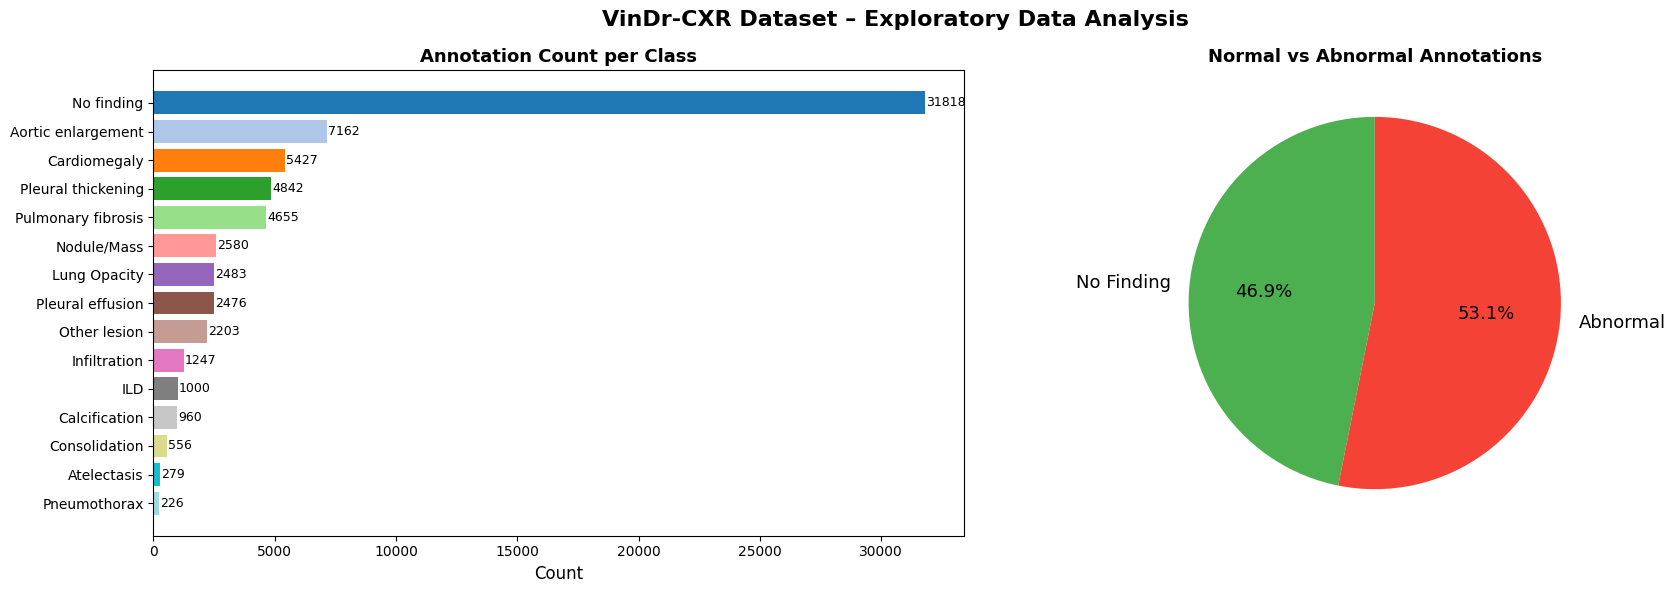

✅ EDA chart saved.


In [8]:
# ── 2.4  EDA – Class distribution chart ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('VinDr-CXR Dataset – Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Bar chart
class_counts = df['class_name'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(class_counts)))
axes[0].barh(class_counts.index, class_counts.values, color=colors)
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_title('Annotation Count per Class', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(class_counts.values):
    axes[0].text(v + 50, i, str(v), va='center', fontsize=9)

# Normal vs Abnormal pie
no_finding = (df['class_name'] == 'No finding').sum()
abnormal   = len(df) - no_finding
axes[1].pie([no_finding, abnormal],
            labels=['No Finding', 'Abnormal'],
            autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'],
            startangle=90,
            textprops={'fontsize': 13})
axes[1].set_title('Normal vs Abnormal Annotations', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA chart saved.')

In [9]:
# ── 2.5  Inspect a single DICOM file ──────────────────────────────────────
sample_dcm_path = train_dicoms[0]
sample_dcm = pydicom.dcmread(sample_dcm_path)

print('🔍 DICOM Metadata (Sample File)')
print(f'  File          : {os.path.basename(sample_dcm_path)}')
print(f'  Rows (Height) : {sample_dcm.Rows}')
print(f'  Cols (Width)  : {sample_dcm.Columns}')
print(f'  Pixel Array   : dtype={sample_dcm.pixel_array.dtype}, shape={sample_dcm.pixel_array.shape}')
print(f'  Min / Max px  : {sample_dcm.pixel_array.min()} / {sample_dcm.pixel_array.max()}')

🔍 DICOM Metadata (Sample File)
  File          : 000434271f63a053c4128a0ba6352c7f.dicom
  Rows (Height) : 2836
  Cols (Width)  : 2336
  Pixel Array   : dtype=uint16, shape=(2836, 2336)
  Min / Max px  : 0 / 4095


---
## 🔄 Section 3: DICOM → PNG Conversion
We apply VOI LUT windowing to get correct contrast, then normalize pixel values to 8-bit [0, 255] and resize to **1024 × 1024**.

In [10]:
# ── 3.1  Conversion function ───────────────────────────────────────────────
from pydicom.pixel_data_handlers.util import apply_voi_lut

TARGET_SIZE = (1024, 1024)   # resize target

def dicom_to_png(dicom_path: str, out_path: str, size: tuple = TARGET_SIZE) -> tuple:
    """
    Convert a single DICOM file to a normalized 8-bit PNG.

    Steps:
      1. Read DICOM with pydicom.
      2. Apply VOI LUT windowing (if available) for proper contrast.
      3. Normalize pixel array to [0, 255] uint8.
      4. Resize with OpenCV (INTER_LINEAR for upscale, INTER_AREA for downscale).
      5. Save as PNG.

    Returns: (original_height, original_width)
    """
    dcm = pydicom.dcmread(dicom_path)
    img = dcm.pixel_array.astype(np.float32)

    # Apply VOI LUT for correct window-level/width
    try:
        img = apply_voi_lut(img, dcm)
    except Exception:
        pass  # fall back to raw pixel array if no VOI LUT

    # Handle MONOCHROME1 (invert so lungs appear dark on white)
    if hasattr(dcm, 'PhotometricInterpretation'):
        if dcm.PhotometricInterpretation == 'MONOCHROME1':
            img = img.max() - img

    orig_h, orig_w = img.shape[:2]

    # Normalize to [0, 255]
    img -= img.min()
    if img.max() > 0:
        img /= img.max()
    img = (img * 255).astype(np.uint8)

    # Resize
    inter = cv2.INTER_AREA if (orig_h > size[0] or orig_w > size[1]) else cv2.INTER_LINEAR
    img = cv2.resize(img, size, interpolation=inter)

    # Save
    cv2.imwrite(out_path, img)
    return orig_h, orig_w

print('✅ dicom_to_png() function defined.')

✅ dicom_to_png() function defined.


✅ Sample converted: original 2836×2336 → saved as 1024×1024 PNG
   Output shape   : (1024, 1024)
   Pixel range    : [0, 255]


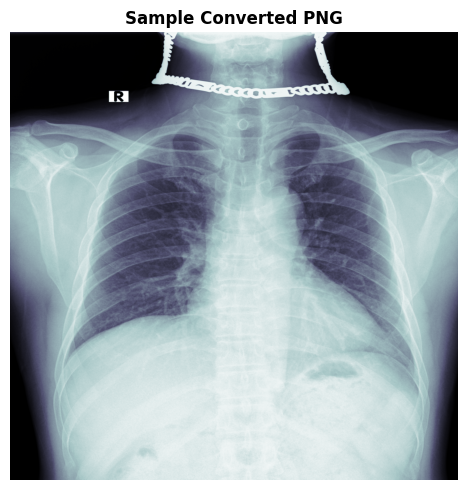

In [11]:
# ── 3.2  Test conversion on 1 sample ──────────────────────────────────────
test_out = f'{OUTPUT_DIR}/sample_test.png'
h, w = dicom_to_png(sample_dcm_path, test_out)
print(f'✅ Sample converted: original {h}×{w} → saved as 1024×1024 PNG')

img_check = cv2.imread(test_out, cv2.IMREAD_GRAYSCALE)
print(f'   Output shape   : {img_check.shape}')
print(f'   Pixel range    : [{img_check.min()}, {img_check.max()}]')

plt.figure(figsize=(5, 5))
plt.imshow(img_check, cmap='bone')
plt.title('Sample Converted PNG', fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 📝 Section 4: Annotation Parsing & YOLO Format Conversion

YOLO format per row:  
```
<class_id>  <x_center>  <y_center>  <width>  <height>
```
All values are **normalized** to [0, 1] relative to image dimensions.

In [12]:
# ── 4.1  Define 14 class labels ────────────────────────────────────────────
CLASS_NAMES = [
    'Aortic enlargement',   # 0
    'Atelectasis',           # 1
    'Calcification',         # 2
    'Cardiomegaly',          # 3
    'Consolidation',         # 4
    'ILD',                   # 5
    'Infiltration',          # 6
    'Lung Opacity',          # 7
    'Nodule/Mass',           # 8
    'Other lesion',          # 9
    'Pleural effusion',      # 10
    'Pleural thickening',    # 11
    'Pneumothorax',          # 12
    'Pulmonary fibrosis',    # 13
    # 'No finding' is EXCLUDED from YOLO labels (no bounding box)
]

CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

print('Class → ID mapping:')
for name, cid in CLASS_TO_ID.items():
    print(f'  [{cid:2d}] {name}')

Class → ID mapping:
  [ 0] Aortic enlargement
  [ 1] Atelectasis
  [ 2] Calcification
  [ 3] Cardiomegaly
  [ 4] Consolidation
  [ 5] ILD
  [ 6] Infiltration
  [ 7] Lung Opacity
  [ 8] Nodule/Mass
  [ 9] Other lesion
  [10] Pleural effusion
  [11] Pleural thickening
  [12] Pneumothorax
  [13] Pulmonary fibrosis


In [13]:
# ── 4.2  Pre-build annotation lookup (group by image_id) ──────────────────
# Filter out 'No finding' rows (they have no bbox)
df_findings = df[df['class_name'] != 'No finding'].copy()
df_findings['class_id'] = df_findings['class_name'].map(CLASS_TO_ID)

# Drop rows where class_id is NaN (unknown classes)
df_findings.dropna(subset=['class_id'], inplace=True)
df_findings['class_id'] = df_findings['class_id'].astype(int)

# Group by image_id for fast lookup
# VinDr-CXR has multiple radiologists (rad_id) annotating the same image.
# Strategy: Keep all annotations (consensus bboxes reduce noise naturally during training).
annot_groups = df_findings.groupby('image_id')

print(f'Total images with findings : {len(annot_groups):,}')
print(f'Total finding annotations  : {len(df_findings):,}')

# Images with no finding at all
no_finding_ids = set(df[df['class_name'] == 'No finding']['image_id'])
print(f'Images labeled No Finding  : {len(no_finding_ids):,}')

Total images with findings : 4,394
Total finding annotations  : 36,096
Images labeled No Finding  : 10,606


In [14]:
# ── 4.3  CSV → YOLO conversion function ──────────────────────────────────
def csv_to_yolo(rows: pd.DataFrame, orig_h: int, orig_w: int) -> list:
    """
    Convert annotation rows for a single image to YOLO format.

    Args:
        rows     : DataFrame rows for this image_id
        orig_h   : original DICOM image height (pixels)
        orig_w   : original DICOM image width  (pixels)

    Returns:
        List of strings: 'class_id x_c y_c w h' (all normalized 0-1)
    """
    lines = []
    for _, row in rows.iterrows():
        x_min = float(row['x_min'])
        y_min = float(row['y_min'])
        x_max = float(row['x_max'])
        y_max = float(row['y_max'])

        # Skip degenerate boxes
        if x_max <= x_min or y_max <= y_min:
            continue

        x_c = ((x_min + x_max) / 2) / orig_w
        y_c = ((y_min + y_max) / 2) / orig_h
        bw  = (x_max - x_min) / orig_w
        bh  = (y_max - y_min) / orig_h

        # Clip to [0, 1]
        x_c = np.clip(x_c, 0.0, 1.0)
        y_c = np.clip(y_c, 0.0, 1.0)
        bw  = np.clip(bw,  0.0, 1.0)
        bh  = np.clip(bh,  0.0, 1.0)

        lines.append(f"{int(row['class_id'])} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}")
    return lines

print('✅ csv_to_yolo() function defined.')

✅ csv_to_yolo() function defined.


---
## ✂️ Section 5: Train / Validation Split & Full Processing Pipeline

In [15]:
# ── 5.1  Get all unique image IDs and split 80/20 ─────────────────────────
all_image_ids = df['image_id'].unique().tolist()
train_ids, val_ids = train_test_split(all_image_ids, test_size=0.20, random_state=42)

print(f'Total images    : {len(all_image_ids):,}')
print(f'Train set       : {len(train_ids):,} ({len(train_ids)/len(all_image_ids)*100:.1f}%)')
print(f'Validation set  : {len(val_ids):,}  ({len(val_ids)/len(all_image_ids)*100:.1f}%)')

# Build a mapping: image_id → 'train' or 'val'
split_map = {img_id: 'train' for img_id in train_ids}
split_map.update({img_id: 'val' for img_id in val_ids})

Total images    : 15,000
Train set       : 12,000 (80.0%)
Validation set  : 3,000  (20.0%)


In [16]:
# ── 5.2  Full pipeline: convert all DICOMs + write YOLO labels ────────────
# Store original dims for YOLO coordinate scaling
orig_dims = {}   # { image_id: (orig_h, orig_w) }
success, failed = 0, 0
errors = []

for dcm_path in tqdm(train_dicoms, desc='Converting DICOM → PNG + YOLO labels'):
    image_id = os.path.splitext(os.path.basename(dcm_path))[0]
    split    = split_map.get(image_id, 'train')

    img_out_dir = IMG_TRAIN if split == 'train' else IMG_VAL
    lbl_out_dir = LBL_TRAIN if split == 'train' else LBL_VAL

    png_path = os.path.join(img_out_dir, f'{image_id}.png')
    lbl_path = os.path.join(lbl_out_dir, f'{image_id}.txt')

    try:
        # Convert DICOM → PNG and store original dimensions
        orig_h, orig_w = dicom_to_png(dcm_path, png_path)
        orig_dims[image_id] = (orig_h, orig_w)

        # Write YOLO label file
        if image_id in annot_groups.groups:
            rows = annot_groups.get_group(image_id)
            yolo_lines = csv_to_yolo(rows, orig_h, orig_w)
        else:
            yolo_lines = []  # 'No finding' image → empty label file

        with open(lbl_path, 'w') as f:
            f.write('\n'.join(yolo_lines))

        success += 1

    except Exception as e:
        failed += 1
        errors.append((image_id, str(e)))

print(f'\n✅ Conversion complete!')
print(f'   Successful : {success:,}')
print(f'   Failed     : {failed:,}')
if errors:
    print('\nFailed files:')
    for img_id, err in errors[:10]:
        print(f'  {img_id}: {err}')

Converting DICOM → PNG + YOLO labels:   0%|          | 0/15000 [00:00<?, ?it/s]


✅ Conversion complete!
   Successful : 15,000
   Failed     : 0


In [17]:
# ── 5.3  Verify output file counts ────────────────────────────────────────
img_train_count = len(glob.glob(os.path.join(IMG_TRAIN, '*.png')))
img_val_count   = len(glob.glob(os.path.join(IMG_VAL, '*.png')))
lbl_train_count = len(glob.glob(os.path.join(LBL_TRAIN, '*.txt')))
lbl_val_count   = len(glob.glob(os.path.join(LBL_VAL, '*.txt')))

print('='*40)
print('📂 OUTPUT DIRECTORY COUNTS')
print('='*40)
print(f'  images/train  : {img_train_count:,} PNGs')
print(f'  images/val    : {img_val_count:,} PNGs')
print(f'  labels/train  : {lbl_train_count:,} TXTs')
print(f'  labels/val    : {lbl_val_count:,} TXTs')
print()

# Sanity check: image count == label count
assert img_train_count == lbl_train_count, '❌ Mismatch in train set!'
assert img_val_count   == lbl_val_count,   '❌ Mismatch in val set!'
print('✅ Image and label counts match for both splits!')

📂 OUTPUT DIRECTORY COUNTS
  images/train  : 12,000 PNGs
  images/val    : 3,000 PNGs
  labels/train  : 12,000 TXTs
  labels/val    : 3,000 TXTs

✅ Image and label counts match for both splits!


In [18]:
# ── 5.4  Validate YOLO label format ───────────────────────────────────────
def validate_yolo_labels(label_dir: str, n_samples: int = 200) -> dict:
    """
    Check that all values in YOLO labels are normalized within [0, 1].
    Returns a dict with pass/fail counts.
    """
    label_files = glob.glob(os.path.join(label_dir, '*.txt'))
    sample_files = random.sample(label_files, min(n_samples, len(label_files)))

    passed, failed_files = 0, []
    for lbl_path in sample_files:
        with open(lbl_path) as f:
            lines = f.read().strip().splitlines()
        ok = True
        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                ok = False; break
            vals = list(map(float, parts[1:]))
            if not all(0.0 <= v <= 1.0 for v in vals):
                ok = False; break
        if ok:
            passed += 1
        else:
            failed_files.append(lbl_path)
    return {'checked': len(sample_files), 'passed': passed, 'failed': len(failed_files)}

result = validate_yolo_labels(LBL_TRAIN, n_samples=300)
print(f'Label validation (train): {result}')

result_val = validate_yolo_labels(LBL_VAL, n_samples=100)
print(f'Label validation (val)  : {result_val}')

Label validation (train): {'checked': 300, 'passed': 300, 'failed': 0}
Label validation (val)  : {'checked': 100, 'passed': 100, 'failed': 0}


---
## 🗂️ Section 6: Generate data.yaml for YOLOv8

In [19]:
# ── 6.1  Write data.yaml ───────────────────────────────────────────────────
import yaml

data_yaml = {
    'path' : os.path.join(OUTPUT_DIR, 'dataset'),
    'train': 'images/train',
    'val'  : 'images/val',
    'nc'   : len(CLASS_NAMES),
    'names': CLASS_NAMES
}

yaml_path = os.path.join(OUTPUT_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True, sort_keys=False)

print('✅ data.yaml created at:', yaml_path)
print()
with open(yaml_path) as f:
    print(f.read())

✅ data.yaml created at: /kaggle/working/cliniscan/data.yaml

path: /kaggle/working/cliniscan/dataset
train: images/train
val: images/val
nc: 14
names:
- Aortic enlargement
- Atelectasis
- Calcification
- Cardiomegaly
- Consolidation
- ILD
- Infiltration
- Lung Opacity
- Nodule/Mass
- Other lesion
- Pleural effusion
- Pleural thickening
- Pneumothorax
- Pulmonary fibrosis



---
## 🖼️ Section 7: Visualization & Verification
Display converted PNGs with their bounding boxes drawn on top.

In [20]:
# ── 7.1  Draw bounding boxes from YOLO label ───────────────────────────────
# Colormap for 14 classes
COLORS = plt.cm.tab20(np.linspace(0, 1, 14))

def draw_yolo_boxes(png_path: str, lbl_path: str, ax, title: str = ''):
    """
    Read a PNG and its YOLO label, draw bounding boxes on the given Axes.
    """
    img = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    H, W = img.shape
    ax.imshow(img, cmap='bone')

    with open(lbl_path) as f:
        lines = f.read().strip().splitlines()

    for line in lines:
        if not line:
            continue
        parts = line.split()
        cls  = int(parts[0])
        x_c  = float(parts[1]) * W
        y_c  = float(parts[2]) * H
        bw   = float(parts[3]) * W
        bh   = float(parts[4]) * H

        x0 = x_c - bw / 2
        y0 = y_c - bh / 2
        color = COLORS[cls % 14]

        rect = patches.Rectangle((x0, y0), bw, bh,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        label = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
        ax.text(x0, y0 - 5, label, color=color, fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')

print('✅ draw_yolo_boxes() defined.')

✅ draw_yolo_boxes() defined.


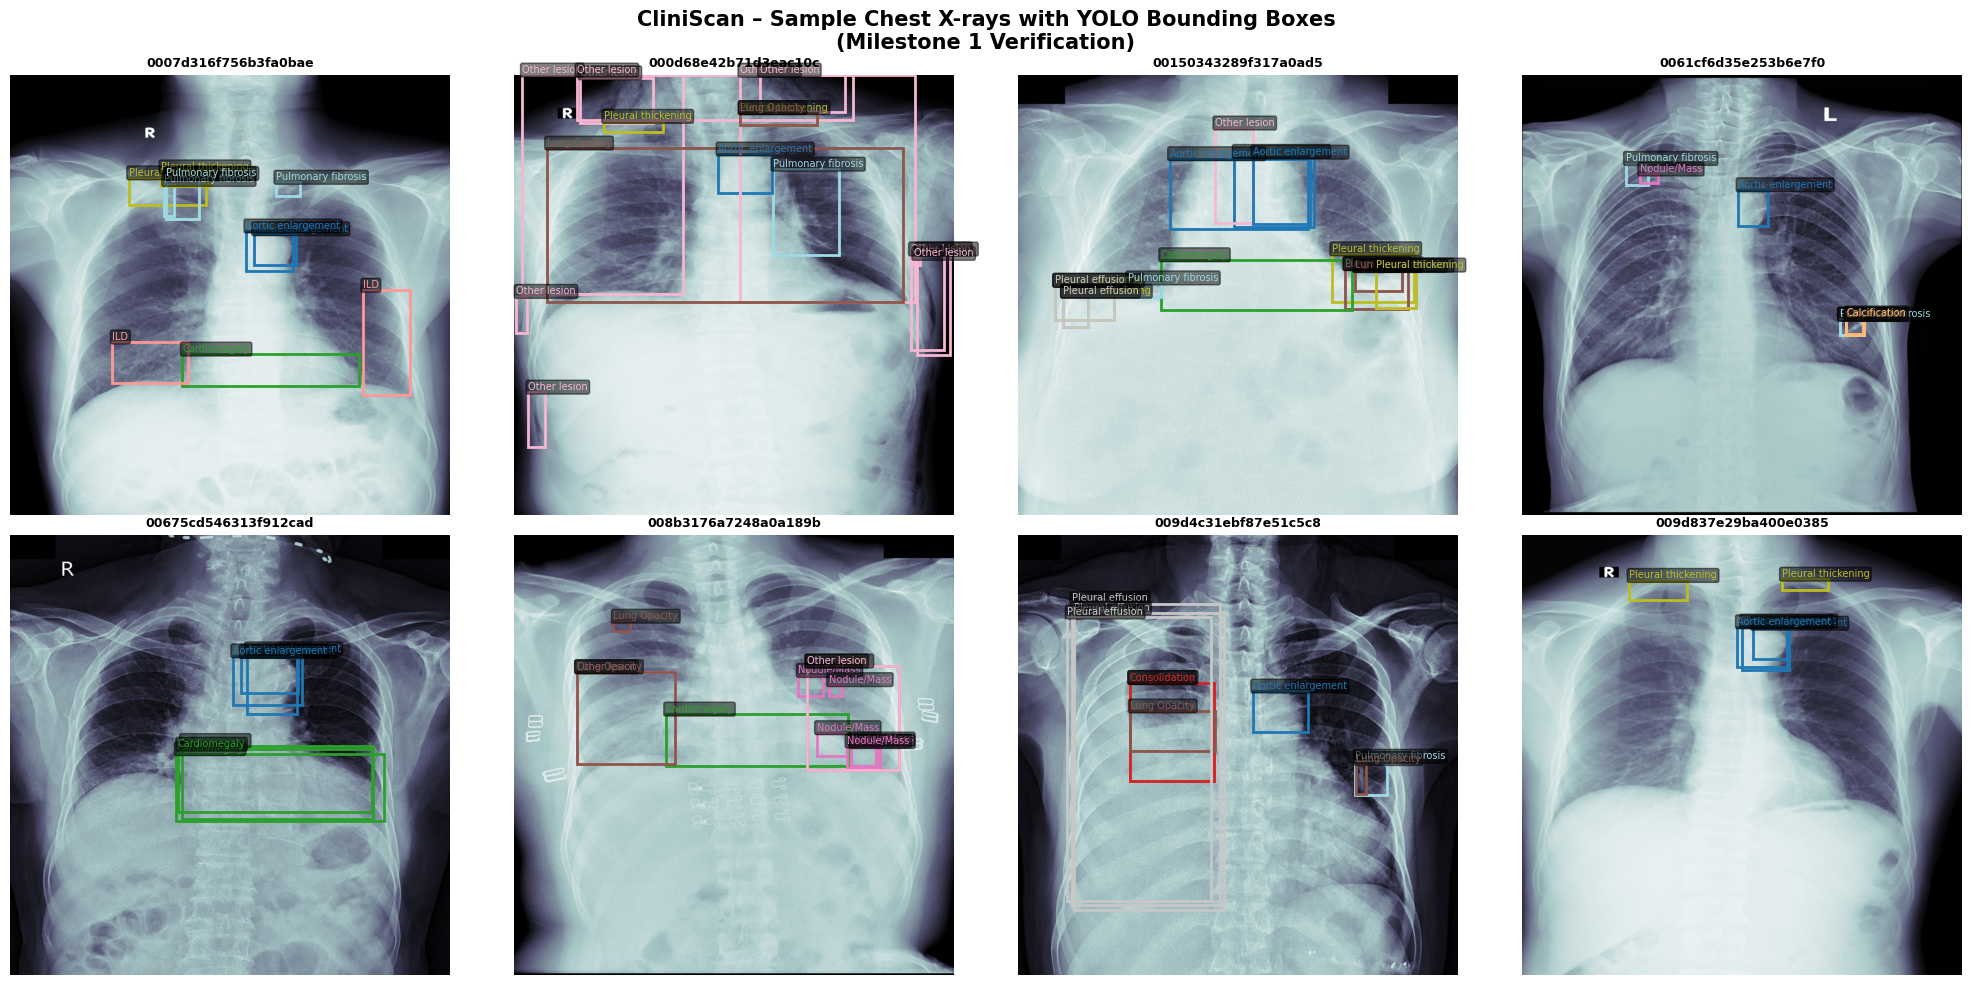

✅ Verification plot saved.


In [21]:
# ── 7.2  Display 8 sample images with bounding boxes ──────────────────────
png_files = sorted(glob.glob(os.path.join(IMG_TRAIN, '*.png')))

# Pick images that actually have annotations
samples = []
for p in png_files:
    img_id = os.path.splitext(os.path.basename(p))[0]
    lbl_p  = os.path.join(LBL_TRAIN, f'{img_id}.txt')
    if os.path.exists(lbl_p) and os.path.getsize(lbl_p) > 0:
        samples.append((p, lbl_p, img_id))
    if len(samples) == 8:
        break

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('CliniScan – Sample Chest X-rays with YOLO Bounding Boxes\n(Milestone 1 Verification)',
             fontsize=15, fontweight='bold')

for i, (png_path, lbl_path, img_id) in enumerate(samples):
    ax = axes[i // 4][i % 4]
    draw_yolo_boxes(png_path, lbl_path, ax, title=img_id[:20])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/milestone1_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Verification plot saved.')

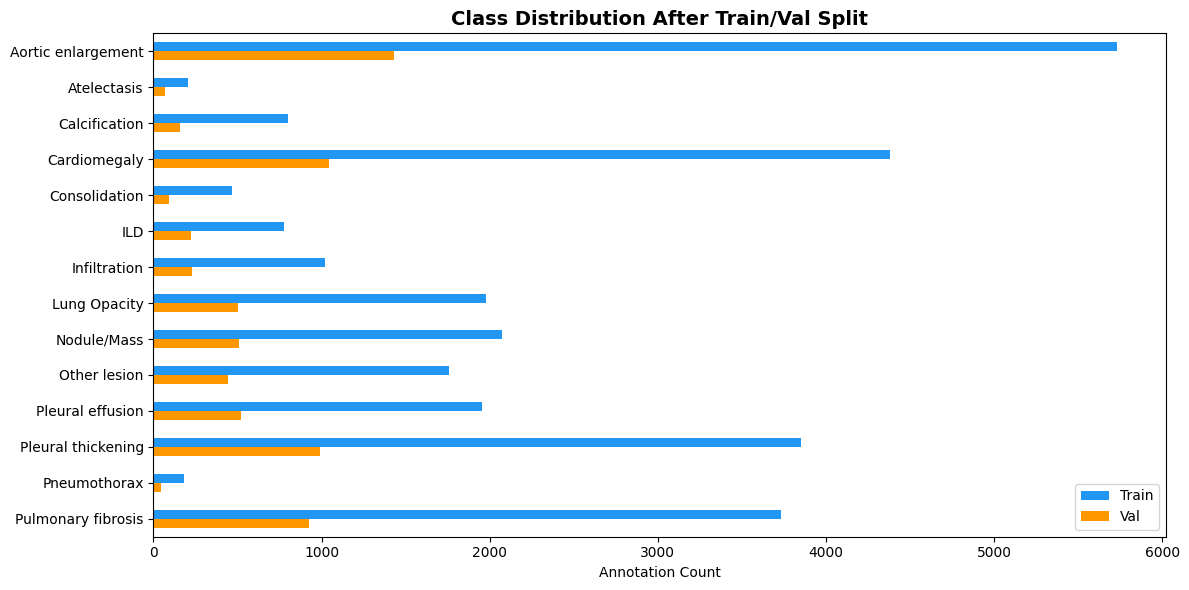

                    Train   Val
Aortic enlargement   5734  1428
Atelectasis           208    71
Calcification         800   160
Cardiomegaly         4381  1046
Consolidation         466    90
ILD                   777   223
Infiltration         1018   229
Lung Opacity         1979   504
Nodule/Mass          2072   508
Other lesion         1757   446
Pleural effusion     1955   521
Pleural thickening   3854   988
Pneumothorax          184    42
Pulmonary fibrosis   3730   925


In [22]:
# ── 7.3  Class distribution after split ───────────────────────────────────
def count_classes_in_split(label_dir: str) -> dict:
    counts = {n: 0 for n in CLASS_NAMES}
    for lbl_path in glob.glob(os.path.join(label_dir, '*.txt')):
        with open(lbl_path) as f:
            for line in f:
                line = line.strip()
                if line:
                    cls = int(line.split()[0])
                    if cls < len(CLASS_NAMES):
                        counts[CLASS_NAMES[cls]] += 1
    return counts

train_counts = count_classes_in_split(LBL_TRAIN)
val_counts   = count_classes_in_split(LBL_VAL)

count_df = pd.DataFrame({'Train': train_counts, 'Val': val_counts})

fig, ax = plt.subplots(figsize=(12, 6))
count_df.plot(kind='barh', ax=ax, color=['#2196F3', '#FF9800'])
ax.set_title('Class Distribution After Train/Val Split', fontsize=14, fontweight='bold')
ax.set_xlabel('Annotation Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution_split.png', dpi=150, bbox_inches='tight')
plt.show()
print(count_df.to_string())

---
## ✅ Section 8: Milestone 1 Summary Report

In [23]:
# ── 8.1  Final summary ─────────────────────────────────────────────────────
print('=' * 65)
print('  🫁  CliniScan – MILESTONE 1 COMPLETION REPORT')
print('=' * 65)

print(f'\n📦  Dataset               : VinDr-CXR (Kaggle Competition)')
print(f'📊  Total Annotations     : {len(df):,} rows in train.csv')
print(f'🖼️   Total Images Converted: {success:,} DICOM → PNG (1024×1024)')
print(f'⚠️   Failed Conversions    : {failed}')
print()
print(f'✂️   Train/Val Split (80/20):')
print(f'    images/train  : {img_train_count:,}')
print(f'    images/val    : {img_val_count:,}')
print(f'    labels/train  : {lbl_train_count:,}')
print(f'    labels/val    : {lbl_val_count:,}')
print()
print(f'📁  Output Directory      : {OUTPUT_DIR}')
print(f'📄  data.yaml             : {yaml_path}')
print()
print('✅  Milestone 1 Objectives Completed:')
print('   [✓] Development environment set up')
print('   [✓] Dataset downloaded and explored (EDA)')
print('   [✓] DICOM → PNG conversion with VOI LUT windowing')
print('   [✓] Annotations parsed (CSV → YOLO format)')
print('   [✓] Train / Validation split (80/20)')
print('   [✓] data.yaml generated for YOLOv8')
print('   [✓] Sample visualization with bounding boxes')
print('   [✓] YOLO label validation passed')
print()
print('🚀  Ready for Milestone 2: Model Development & Baseline Training!')
print('=' * 65)

  🫁  CliniScan – MILESTONE 1 COMPLETION REPORT

📦  Dataset               : VinDr-CXR (Kaggle Competition)
📊  Total Annotations     : 67,914 rows in train.csv
🖼️   Total Images Converted: 15,000 DICOM → PNG (1024×1024)
⚠️   Failed Conversions    : 0

✂️   Train/Val Split (80/20):
    images/train  : 12,000
    images/val    : 3,000
    labels/train  : 12,000
    labels/val    : 3,000

📁  Output Directory      : /kaggle/working/cliniscan
📄  data.yaml             : /kaggle/working/cliniscan/data.yaml

✅  Milestone 1 Objectives Completed:
   [✓] Development environment set up
   [✓] Dataset downloaded and explored (EDA)
   [✓] DICOM → PNG conversion with VOI LUT windowing
   [✓] Annotations parsed (CSV → YOLO format)
   [✓] Train / Validation split (80/20)
   [✓] data.yaml generated for YOLOv8
   [✓] Sample visualization with bounding boxes
   [✓] YOLO label validation passed

🚀  Ready for Milestone 2: Model Development & Baseline Training!


In [24]:
# ── 8.2  List all output files ─────────────────────────────────────────────
print('📂 Generated Artifacts:')
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # only show files at depth ≤ 2
        subindent = '  ' * (level + 1)
        for f in files:
            size = os.path.getsize(os.path.join(root, f))
            print(f'{subindent}{f}  ({size:,} bytes)')

📂 Generated Artifacts:
cliniscan/
  sample_test.png  (439,165 bytes)
  milestone1_verification.png  (4,259,605 bytes)
  class_distribution_split.png  (69,122 bytes)
  data.yaml  (313 bytes)
  eda_class_distribution.png  (131,729 bytes)
  dataset/
    images/
      train/
      val/
    labels/
      train/
      val/
